In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [21]:
train=pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test=pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [22]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


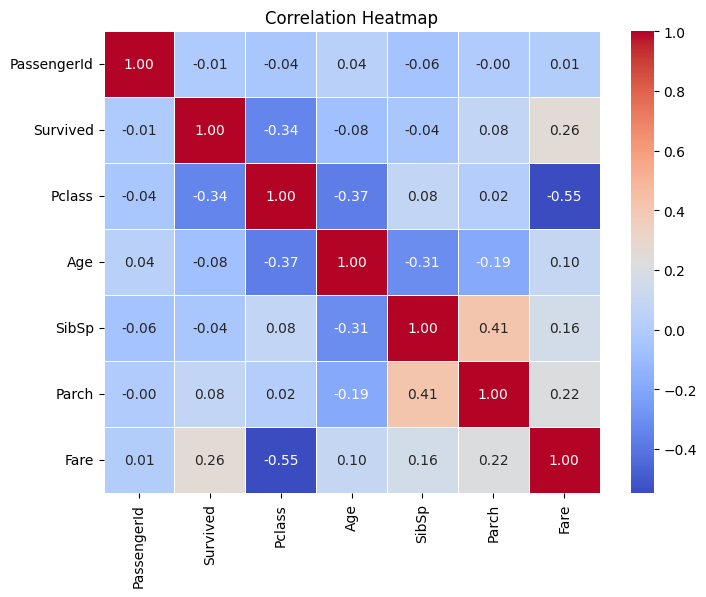

In [25]:
numeric_train = train.select_dtypes(include=['number'])
corr_matrix = numeric_train.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
train.drop(["Cabin","Ticket","Name"], axis=1, inplace=True)

train["Age"].fillna(train["Age"].mean(), inplace=True)

train.dropna(subset=["Embarked"], inplace=True)

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

train['Sex'] = le.fit_transform(train['Sex'])
train["Embarked"] = le.fit_transform(train["Embarked"]) 

In [28]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

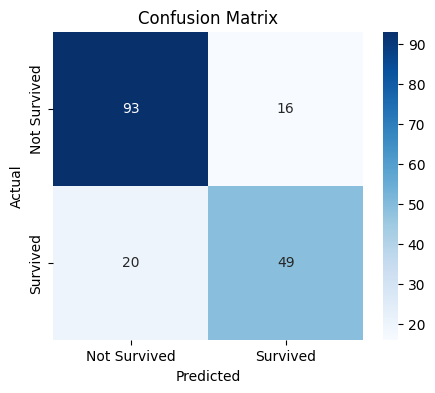

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, model.predict(X_test))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
test.drop(["Cabin","Ticket","Name"], axis=1, inplace=True)

test["Age"].fillna(test["Age"].mean(), inplace=True)

test.dropna(subset=["Embarked"], inplace=True)

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

test['Sex'] = le.fit_transform(test['Sex'])
test["Embarked"] = le.fit_transform(test["Embarked"]) # S=2, C=0, Q=1

In [32]:
test["Fare"].fillna(test["Fare"].mean(), inplace=True)

In [33]:
y_pred = model.predict(test)

In [41]:
from sklearn.linear_model import SGDClassifier 
model_sgd=SGDClassifier(
    loss="log_loss",     
    random_state=42,
    max_iter=1000,
    tol=1e-3
)
model_sgd.fit(X_train,y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [35]:
y_pred_sgd = model_sgd.predict(test)

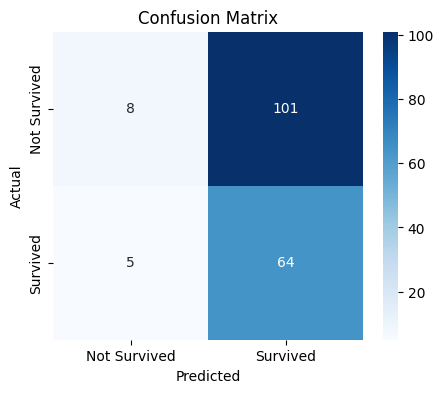

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on the validation/test split
y_pred = model_sgd.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": y_pred_sgd
})

In [40]:
submission.to_csv("submission.csv", index=False)